<a href="https://colab.research.google.com/github/ButenkoYuliia/customer-segmentation/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

df = pd.read_csv('/content/job_jBrpsTWMISpN-pCrKl58Y_YTqGT7.csv')

In [6]:
print(df.shape)

(2781, 18)


In [7]:
print(df.describe().round(2).T)

                  count       mean       std       min        25%        50%  \
account_id       2781.0  658815.53  13140.19  636138.0  647432.00  658322.00   
order_sum        2781.0     928.63   1319.68       3.0     150.00     399.00   
items_cnt        2781.0       1.00      0.00       1.0       1.00       1.00   
categories_cnt   2781.0       1.00      0.00       1.0       1.00       1.00   
avg_item_price   2781.0     928.63   1319.68       3.0     150.00     399.00   
emails_sent      2781.0      19.09     39.26       0.0       0.00       0.00   
emails_opened    2781.0       6.99     20.82       0.0       0.00       0.00   
emails_visited   2781.0       0.78      2.92       0.0       0.00       0.00   
open_rate        1038.0       0.37      0.38       0.0       0.01       0.22   
visit_rate       1038.0       0.04      0.09       0.0       0.00       0.00   
is_verified      2781.0       0.72      0.45       0.0       0.00       1.00   
is_unsubscribed  2781.0       0.16      

In [8]:
# Самое важное: сколько РАЗНЫХ значений в ключевых признаках
# Assuming these columns exist in the loaded DataFrame. Adjust if necessary.
for col in ['items_cnt', 'categories_cnt', 'emails_sent', 'emails_opened', 'emails_visited']:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts().head(10))
    else:
        print(f'\nColumn "{col}" not found in DataFrame.')


items_cnt:
items_cnt
1    2781
Name: count, dtype: int64

categories_cnt:
categories_cnt
1    2781
Name: count, dtype: int64

emails_sent:
emails_sent
0     1743
3      116
2      110
1       29
4       14
5       14
20      13
8       13
52      12
30      12
Name: count, dtype: int64

emails_opened:
emails_opened
0    1997
1      99
2      77
3      42
5      36
6      32
4      31
7      22
8      21
9      20
Name: count, dtype: int64

emails_visited:
emails_visited
0     2317
1      155
2       73
3       49
4       45
6       29
5       18
7       16
9       14
10       9
Name: count, dtype: int64


In [9]:
import numpy as np

em = df[df['emails_sent'] > 0].copy()
print('Клиентов с рассылкой:', len(em))

# Логарифм сглаживает «длинный хвост» у сумм и числа писем
em['log_order_sum'] = np.log1p(em['order_sum'])
em['log_emails_sent'] = np.log1p(em['emails_sent'])

features = ['log_order_sum', 'log_emails_sent', 'open_rate', 'visit_rate']
X = em[features]

Клиентов с рассылкой: 1038


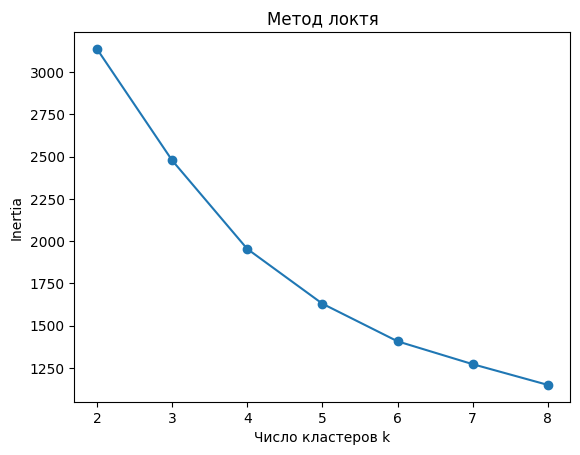

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_scaled = StandardScaler().fit_transform(X)

inertia = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('Число кластеров k'); plt.ylabel('Inertia')
plt.title('Метод локтя'); plt.show()

In [11]:
from sklearn.metrics import silhouette_score

for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    print(k, round(silhouette_score(X_scaled, labels), 3))

2 0.301
3 0.303
4 0.323
5 0.323
6 0.328
7 0.327
8 0.306


In [12]:
k = 4   # поменяем, если силуэт подскажет другое
km = KMeans(n_clusters=k, random_state=42, n_init=10)
em['cluster'] = km.fit_predict(X_scaled)

profile = em.groupby('cluster').agg(
    clients=('account_id', 'count'),
    order_sum_median=('order_sum', 'median'),
    emails_sent_median=('emails_sent', 'median'),
    open_rate_mean=('open_rate', 'mean'),
    visit_rate_mean=('visit_rate', 'mean'),
).round(2)
print(profile)

         clients  order_sum_median  emails_sent_median  open_rate_mean  \
cluster                                                                  
0            246             449.5                43.5            0.90   
1            272             462.5                 3.0            0.15   
2            457             499.0                73.0            0.15   
3             63             255.0                21.0            0.81   

         visit_rate_mean  
cluster                   
0                   0.03  
1                   0.00  
2                   0.03  
3                   0.33  


In [13]:
names = {0: 'Читатели', 1: 'Новички рассылки',
         2: 'Игнорирующие', 3: 'Активные кликеры'}
em['segment'] = em['cluster'].map(names)

# Доля отписавшихся, подтверждённых и средний интервал рассылки
print(em.groupby('segment')[['is_unsubscribed', 'is_verified', 'send_interval']].mean().round(2))

# С каких устройств покупали (доли внутри каждого сегмента)
print(pd.crosstab(em['segment'], em['device'], normalize='index').round(2))

                  is_unsubscribed  is_verified  send_interval
segment                                                      
Активные кликеры             0.37         1.00           1.22
Игнорирующие                 0.07         1.00           1.10
Новички рассылки             0.10         0.29           1.02
Читатели                     0.20         0.85           1.11
device            desktop  mobile  tablet
segment                                  
Активные кликеры     0.57    0.38    0.05
Игнорирующие         0.59    0.40    0.02
Новички рассылки     0.64    0.35    0.01
Читатели             0.57    0.40    0.03


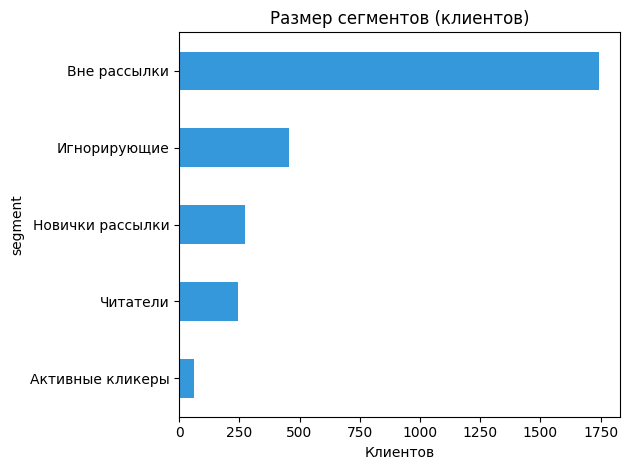

In [15]:
plt.style.use('default')
sizes = em['segment'].value_counts()
sizes['Вне рассылки'] = (df['emails_sent'] == 0).sum()

sizes.sort_values().plot(kind='barh', color='#3498db')
plt.title('Размер сегментов (клиентов)')
plt.xlabel('Клиентов'); plt.tight_layout(); plt.show()

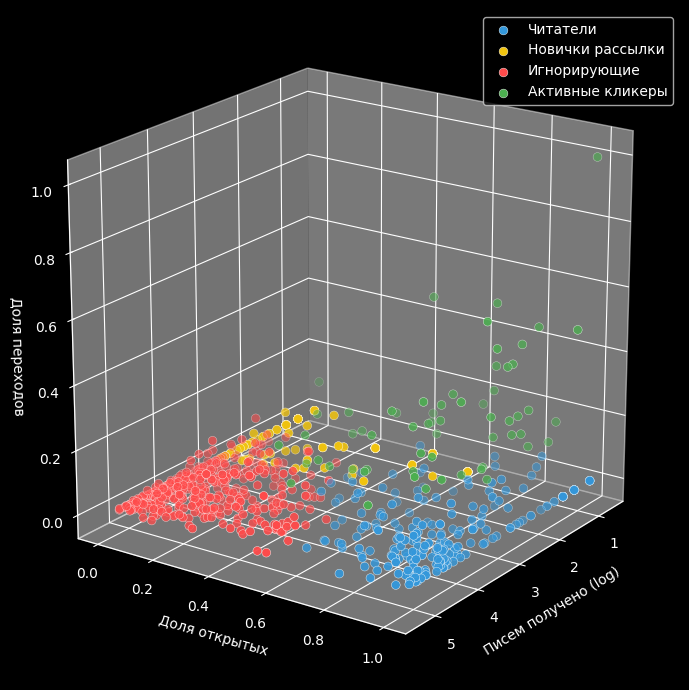

In [17]:
colors = {'Читатели': '#3498db', 'Новички рассылки': '#f1c40f',
          'Игнорирующие': '#ff4b4b', 'Активные кликеры': '#4CAF50'}

plt.style.use('dark_background')
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for seg, color in colors.items():
    part = em[em['segment'] == seg]
    ax.scatter(part['log_emails_sent'], part['open_rate'], part['visit_rate'],
               c=color, s=40, edgecolor='white', linewidth=0.3, label=seg)

ax.set_xlabel('Писем получено (log)')
ax.set_ylabel('Доля открытых')
ax.set_zlabel('Доля переходов')
ax.legend(); ax.view_init(elev=20, azim=35)
# Original line had an incorrect parameter 'zoom' and 'None' for aspect
# Correcting to set a proportional aspect ratio for the 3D box:
ax.set_box_aspect((1, 1, 1))
plt.tight_layout(); plt.show()